In [2]:
# focus on neural network models
# MLP, implement it, go on refining, change parameteres, and observe the changes in the results.
# work on optimizing the model
# explore MLP
# understand neural networks properly, and add more comments

In [3]:
import pandas as pd #used to store, manipulate, clean, and analyze data
import numpy as np #used for numerical computations, working with arrays, and performing mathematical operations 

from sklearn.model_selection import train_test_split #used to split the dataset into training and testing sets
from sklearn.preprocessing import StandardScaler #used to standardize features by removing the mean and scaling to unit variance, which can improve the performance of machine learning algorithms

from sklearn.neural_network import MLPClassifier #used to create a multi-layer perceptron (MLP) classifier, which is a type of feedforward artificial neural network that can be used for classification tasks

from sklearn.metrics import (
    accuracy_score, #used to calculate the accuracy of the model, which is the ratio of correctly predicted instances to the total instances
    confusion_matrix, #used to create a confusion matrix, which shows the counts of true positives, true negatives, false positives, and false negatives
    classification_report, #used to generate a detailed report of the model's performance, including precision, recall, and F1-score for each class
    roc_auc_score, #used to calculate the area under the ROC curve, which is a measure of the model's ability to distinguish between classes
    roc_curve #used to generate the ROC curve, which plots the true positive rate against the false positive rate at various threshold settings
)

import matplotlib.pyplot as plt #used to create visualizations and plots

LOADING THE DATASET

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"

data = pd.read_csv( #used to read the CSV file from the specified URL and load it into a DataFrame
    url,
    sep=';',
    header=None
)

print(data.shape)

(1055, 42)


FEATURING & LABELING

In [5]:
X = data.iloc[:, :-1] #used to select all columns except the last one
y = data.iloc[:, -1] #used to select the last column

y = y.map({'RB':1, 'NRB':0}) #used to map the labels 'RB' and 'NRB' to 1 and 0 respectively

TRAIN/TEST SPLIT

In [6]:
X_train, X_test, y_train, y_test = train_test_split( #used to split the dataset into training and testing sets, with 20% of the data reserved for testing, and stratified sampling to maintain the class distribution
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #
)

SCALING

In [7]:
scaler = StandardScaler() #used to create an instance of the StandardScaler, which will be used to standardize the features by removing the mean and scaling to unit variance. 
X_train = scaler.fit_transform(X_train) #used to fit the StandardScaler to the training data and transform it
X_test = scaler.transform(X_test) #used to transform the test data using the fitted StandardScaler

MLP MODEL

In [8]:
mlp = MLPClassifier( 
    hidden_layer_sizes=(64,32), #used to specify the architecture of the neural network, with two hidden layers containing 64 and 32 neurons respectively
    activation='relu', #used to specify the activation function for the hidden layers, which is ReLU (Rectified Linear Unit) in this case. ReLU is a popular activation function that helps the model learn complex patterns by introducing non-linearity.
    solver='adam',#used to specify the optimization algorithm for training the neural network, which is Adam in this case. 
    #Adam is an adaptive learning rate optimization algorithm that combines the advantages of both AdaGrad and RMSProp.
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42 #used to set the random seed for reproducibility
)

TRAINING & PREDICTING

In [9]:
mlp.fit(X_train, y_train) #used to train the MLP classifier on the training data, allowing it to learn the patterns and relationships in the data to make predictions

y_pred = mlp.predict(X_test) #used to make predictions on the test data using the trained MLP classifier, which will output the predicted class labels for each instance in the test set

y_prob = mlp.predict_proba(X_test)[:,1] #used to get the predicted probabilities for the positive class (class 1) from the MLP classifier, which can be used for evaluating the model's performance

ACCURACY

In [10]:
accuracy = accuracy_score(y_test, y_pred) #used to calculate the accuracy of the model by comparing the true labels (y_test) with the predicted labels (y_pred). The accuracy is the ratio of correctly predicted instances to the total instances in the test set.

print("Accuracy:", accuracy) 

Accuracy: 0.8578199052132701


CONFUSION MATRIX & CLASSIFICATION REPORT

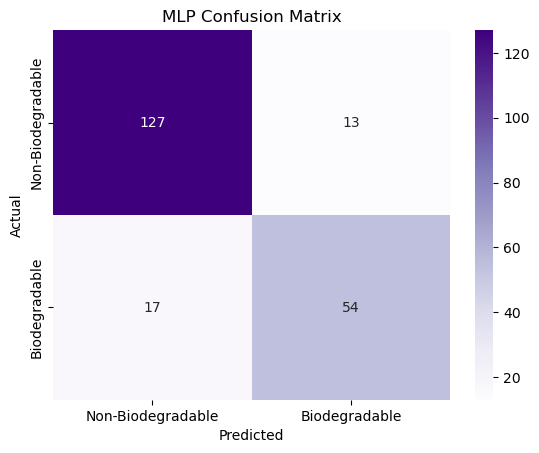


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       140
           1       0.81      0.76      0.78        71

    accuracy                           0.86       211
   macro avg       0.84      0.83      0.84       211
weighted avg       0.86      0.86      0.86       211



In [11]:
cm = confusion_matrix(y_test, y_pred) #used to calculate the confusion matrix, which shows the number of correct and incorrect predictions for each class
import seaborn as sns #used to create a heatmap of the confusion matrix, which provides a visual representation of the model's performance in terms of true positives, true negatives, false positives, and false negatives
sns.heatmap(
    cm,
    annot=True, 
    fmt='d', 
    cmap='Purples', 
    xticklabels=['Non-Biodegradable','Biodegradable'],
    yticklabels=['Non-Biodegradable','Biodegradable']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MLP Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ROC CURVE

ROC-AUC: 0.895774647887324


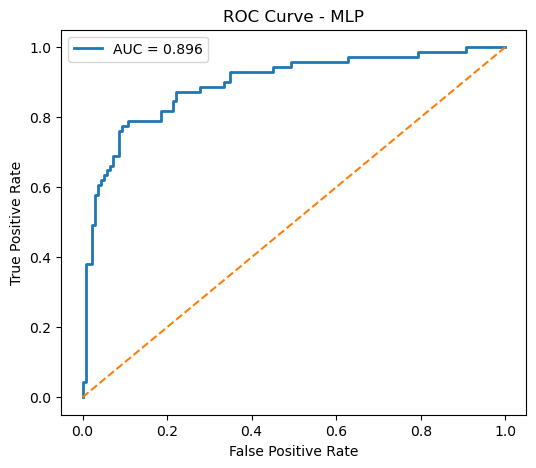

In [12]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5)) #used to create a new figure with a specified size for the ROC curve plot

plt.plot(fpr, tpr, linewidth=2, #used to plot the ROC curve by plotting the false positive rate (fpr) against the true positive rate (tpr), with a specified line width for better visibility
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")
plt.legend() 

plt.show()

In [13]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.0001,
    max_iter=100,
    random_state=42
)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

y_prob = mlp.predict_proba(X_test)[:,1]
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8578199052132701


c:\Users\Aashka Warke\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


USING DIFFERENT SOLVERS

In [ ]:
solvers = ['adam', 'sgd', 'lbfgs'] 
#ADAM: an adaptive optimization algorithm that updates network weights using estimates of first and second moments of gradients
#SGD: Stochastic Gradient Descent, aupdates model weights iteratively using small subsets of training data
#LBFGS: an optimization algorithm that approximates the Broyden–Fletcher–Goldfarb–Shanno algorithm, which is a quasi-Newton optimization algorithm that approximates second-order derivatives to achieve faster convergence and accurate parameter estimation.

results = []

for solver in solvers:

    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver=solver,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    )

    mlp.fit(X_train, y_train)
  
    y_pred = mlp.predict(X_test) 
    y_prob = mlp.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([solver, accuracy, roc_auc])

    print(f"\n{'='*50}")
    print(f"Solver: {solver}")
    print(f"{'='*50}")

    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Solver: adam
Accuracy: 0.8578
ROC-AUC : 0.8958

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       140
           1       0.81      0.76      0.78        71

    accuracy                           0.86       211
   macro avg       0.84      0.83      0.84       211
weighted avg       0.86      0.86      0.86       211



c:\Users\Aashka Warke\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Solver: sgd
Accuracy: 0.8863
ROC-AUC : 0.9186

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       140
           1       0.86      0.79      0.82        71

    accuracy                           0.89       211
   macro avg       0.88      0.86      0.87       211
weighted avg       0.89      0.89      0.88       211


Solver: lbfgs
Accuracy: 0.8436
ROC-AUC : 0.8808

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       140
           1       0.79      0.73      0.76        71

    accuracy                           0.84       211
   macro avg       0.83      0.82      0.82       211
weighted avg       0.84      0.84      0.84       211



In [ ]:
comparison_df = pd.DataFrame( #created a DataFrame to store the results of the different solvers, including their accuracy and ROC-AUC scores. This allows for easy comparison of the performance of each solver.
    results,
    columns=['Solver', 'Accuracy', 'ROC-AUC'] 
)

print(comparison_df)

  Solver  Accuracy   ROC-AUC
0   adam  0.857820  0.895775
1    sgd  0.886256  0.918612
2  lbfgs  0.843602  0.880785


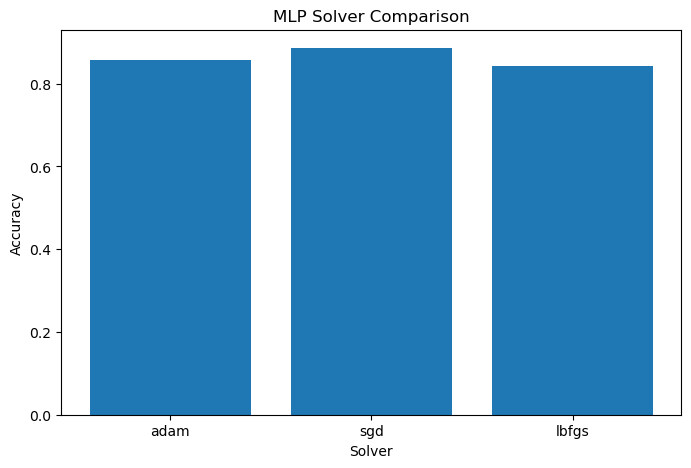

In [20]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Solver'],
    comparison_df['Accuracy']
)

plt.xlabel("Solver")
plt.ylabel("Accuracy")
plt.title("MLP Solver Comparison")

plt.show()

c:\Users\Aashka Warke\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (900) reached and the optimization hasn't converged yet.
  warnings.warn(


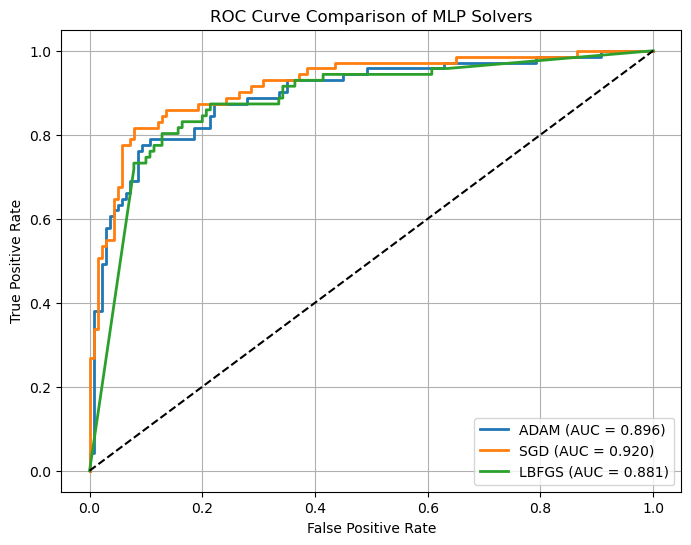

In [26]:

solvers = ['adam', 'sgd', 'lbfgs']

plt.figure(figsize=(8,6))

for solver in solvers:

    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver=solver,
        learning_rate_init=0.001,
        max_iter=900,
        random_state=42
    )

    mlp.fit(X_train, y_train)

    y_prob = mlp.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{solver.upper()} (AUC = {auc_score:.3f})'
    )

# Random classifier reference line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of MLP Solvers')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

In [37]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

activations = ['relu', 'tanh', 'logistic']
solvers = ['adam', 'sgd', 'lbfgs']

results = []

for activation in activations:

    for solver in solvers:

        mlp = MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation=activation,
            solver=solver,
            learning_rate_init=0.001,
            max_iter=1000,
            random_state=42
        )

        mlp.fit(X_train, y_train)

        y_pred = mlp.predict(X_test)
        y_prob = mlp.predict_proba(X_test)[:,1]

        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        results.append([
            activation,
            solver,
            accuracy,
            auc
        ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Activation',
        'Solver',
        'Accuracy',
        'ROC_AUC'
    ]
)

print(results_df.sort_values(
    by='ROC_AUC',
    ascending=False
))

c:\Users\Aashka Warke\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Aashka Warke\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


  Activation Solver  Accuracy   ROC_AUC
4       tanh    sgd  0.857820  0.919316
1       relu    sgd  0.886256  0.918612
6   logistic   adam  0.853081  0.906640
3       tanh   adam  0.857820  0.901610
5       tanh  lbfgs  0.867299  0.898239
0       relu   adam  0.857820  0.895775
2       relu  lbfgs  0.843602  0.880785
8   logistic  lbfgs  0.824645  0.874648
7   logistic    sgd  0.663507  0.576258


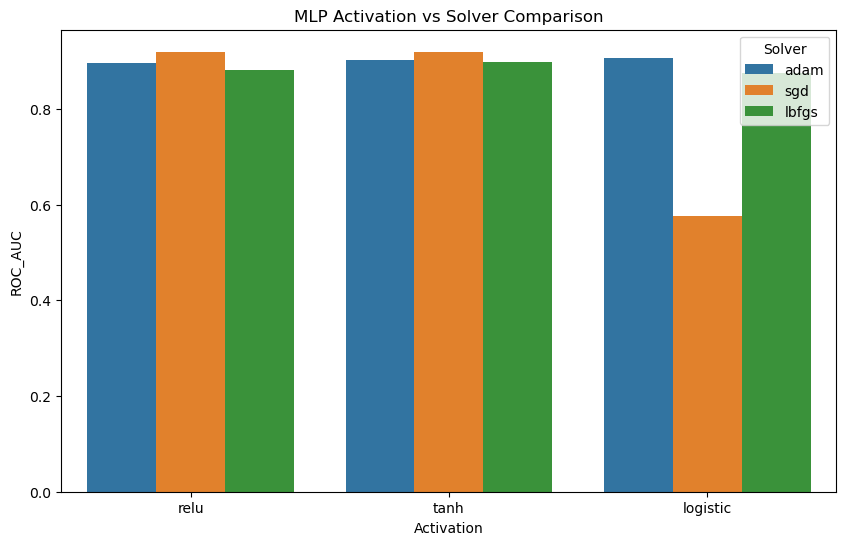

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Activation',
    y='ROC_AUC',
    hue='Solver'
)

plt.title('MLP Activation vs Solver Comparison')
plt.show()

In [40]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [
        (32,),
        (64,32),
        (128,64,32)
    ],
    'activation': [
        'relu',
        'tanh',
        'logistic'
    ],
    'solver': [
        'adam',
        'sgd',
        'lbfgs'
    ],
    'alpha': [
        0.0001,
        0.001,
        0.01
    ]
}

grid = GridSearchCV(
    MLPClassifier(max_iter=1000,
                  random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'activation': 'logistic', 'alpha': 0.01, 'hidden_layer_sizes': (32,), 'solver': 'adam'}
0.928984059247217


c:\Users\Aashka Warke\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
#references: https://www.kaggle.com/code/androbomb/simple-nn-with-python-multi-layer-perceptron/notebook
